<a href="https://colab.research.google.com/github/QangDuc/deeplearning/blob/main/TH_DLN_Tuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ANN

In [3]:
#install required libraries
!pip install scikeras
import pandas as pd
import numpy as np
#data visualization packages
import matplotlib.pyplot as plt
#keras packages
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Convolution2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.layers import Dropout
#model evaluation packages
from sklearn.metrics import f1_score, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

Đọc tập dữ liệu FASHION MNIST

In [2]:
#tải bộ mnist fashion dataset
fashion = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 112s 140ms/step - accuracy: 0.2636 - loss: 3.8448 - val_accuracy: 0.3359 - val_loss: 3.2623
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.3279 - loss: 3.1225 - val_accuracy: 0.3775 - val_loss: 2.7740
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 107s 137ms/step - accuracy: 0.3557 - loss: 2.7087 - val_accuracy: 0.3821 - val_loss: 2.4817
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 109s 139ms/step - accuracy: 0.3718 - loss: 2.3875 - val_accuracy: 0.3889 - val_loss: 2.2563
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 135ms/step - accuracy: 0.3879 - loss: 2.1625 - val_accuracy: 0.3888 - val_loss: 2.0671
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.3939 - loss: 2.0110 - val_accuracy: 0.3553 - val_loss: 2.0341
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 141ms/step - accuracy: 0.3978 - loss: 1.9134 - val_accuracy: 0.3764 - val_loss: 1.9516
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 149ms/step - accuracy: 0.4000 -

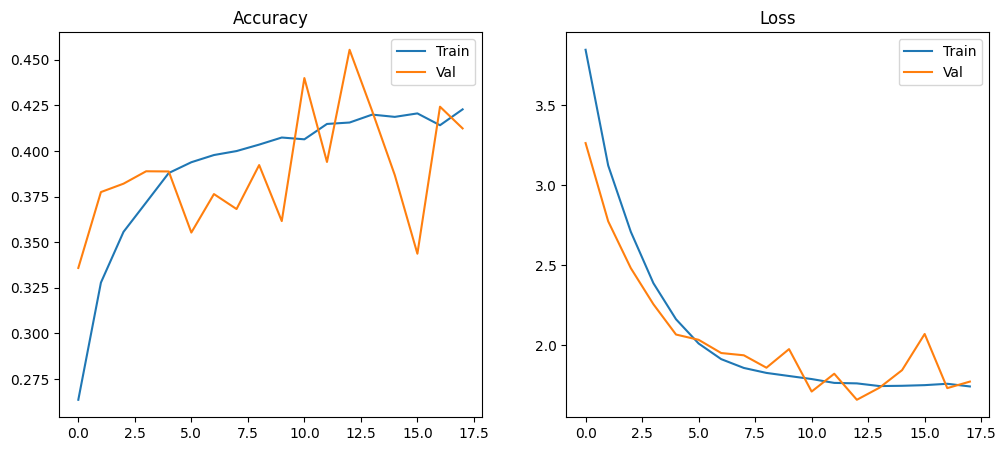

In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers

# LOAD DATA
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# NORMALIZE
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# FLATTEN
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# =====================
# ANN MODEL (IMPROVED OPTION 1)
# =====================
model = models.Sequential()

model.add(layers.Dense(
    2048,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.0005),
    input_shape=(3072,)
))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(
    1024,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.0005)
))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))

model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.4))

model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(10, activation='softmax'))

# =====================
# OPTIMIZER (IMPORTANT)
# =====================
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =====================
# EARLY STOPPING
# =====================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# TRAIN
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# EVALUATE
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", test_acc)

# PREDICT
y_pred = model.predict(X_test)
y_pred_class = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

print("Final Accuracy:", np.mean(y_pred_class == y_true))

# PLOT
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

#Regression

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 99269104.0000 - mean_absolute_error: 8440.3799 - val_loss: 110946824.0000 - val_mean_absolute_error: 8953.2334
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 99177496.0000 - mean_absolute_error: 8437.3008 - val_loss: 110845472.0000 - val_mean_absolute_error: 8949.3867
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 99099432.0000 - mean_absolute_error: 8434.6836 - val_loss: 110712560.0000 - val_mean_absolute_error: 8944.3018
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 99006056.0000 - mean_absolute_error: 8431.0312 - val_loss: 110536952.0000 - val_mean_absolute_error: 8937.5840
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 98891776.0000 - mean_absolute_error: 8426.5898 - val_loss: 110324520.0000 - val_mean_absolute_error: 8929.3359
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 98756840.0000 - mean_absolute_error: 8421.6045 - val_loss: 110125360.0000 - val_mean_absolute_error: 89

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

Mean Squared Error: 21182848.927873004
R² Score: 0.41419965088689104


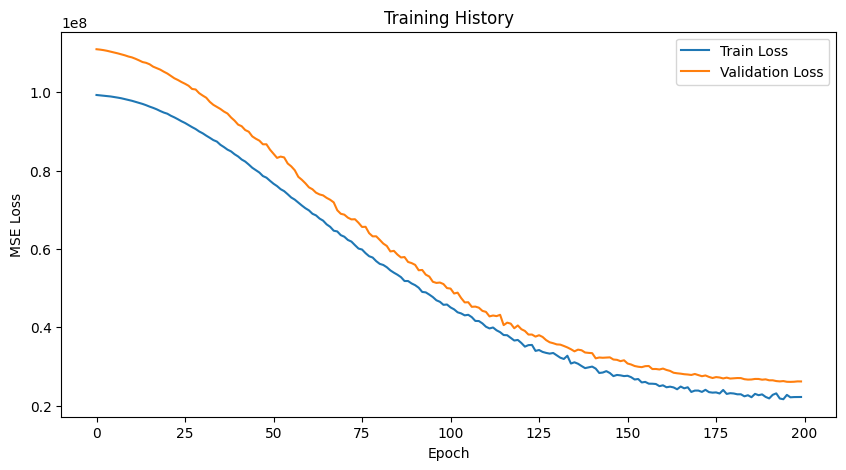

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted house price: 6370.845


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =====================
# 1. TẠO DỮ LIỆU GIẢ LẬP NHIỀU MẪU
# =====================
np.random.seed(42)
n_samples = 2000  # tăng số mẫu để ANN học tốt hơn

# 4 features: diện tích, phòng, tuổi nhà, khoảng cách trung tâm
area = np.random.uniform(30, 200, n_samples)
rooms = np.random.randint(1, 6, n_samples)
age = np.random.randint(0, 50, n_samples)
distance = np.random.uniform(0, 20, n_samples)  # km tới trung tâm

# Price formula + noise
price = 50*area + 2000*rooms - 100*age - 150*distance + np.random.normal(0, 5000, n_samples)

X = np.column_stack([area, rooms, age, distance])
y = price

# =====================
# 2. LOẠI OUTLIER (FEATURE ENGINEERING)
# =====================
mask = (y > np.percentile(y, 1)) & (y < np.percentile(y, 99))
X = X[mask]
y = y[mask]

# =====================
# 3. SPLIT TRAIN/TEST
# =====================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================
# 4. SCALE DATA
# =====================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. BUILD ANN
model = models.Sequential()

model.add(layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(256, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.3))

model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))

model.add(layers.Dense(1, activation='linear'))

# =====================
# 6. COMPILE
# =====================
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# =====================
# 7. EARLY STOPPING
# =====================
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# =====================
# 8. TRAIN
# =====================
history = model.fit(
    X_train, y_train,
    validation_split=0.2
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =====================
# 9. EVALUATE
# =====================
y_pred = model.predict(X_test).flatten()
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nMean Squared Error:", mse)
print("R² Score:", r2)

# =====================
# 10. VISUALIZE LOSS
# =====================
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.show()

# =====================
# 11. DỰ ĐOÁN THỬ 1 MẪU
# =====================
new_sample = np.array([[75, 3, 10, 5]])  # 75m2, 3 phòng, 10 tuổi, 5km trung tâm
new_sample_scaled = scaler.transform(new_sample)
pred_price = model.predict(new_sample_scaled)
print("Predicted house price:", pred_price[0][0])